In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Load dataset
file_path = '/content/global_inflation_post_covid.csv'
df = pd.read_csv(file_path)

print(df.head())

  country     date  inflation_rate  interest_rate  oil_price  gdp_growth  \
0     USA  2020-01            0.33           5.76      34.44        0.34   
1     USA  2020-02            4.12           4.33      44.75        0.02   
2     USA  2020-03            2.75           4.24      52.80        0.30   
3     USA  2020-04            4.36           4.52      39.19        2.28   
4     USA  2020-05            2.73           3.17      41.09        3.05   

   unemployment_rate  money_supply_m2  exchange_rate_usd  food_price_index  \
0               5.97          10558.0              69.95             94.29   
1               5.80           6952.0              71.03             78.60   
2               7.45          10244.0              71.00            102.91   
3               5.23           9989.0              83.52            110.92   
4               5.96           7982.0              70.10             86.53   

   supply_chain_index  
0                3.66  
1                3.91  
2 

In [3]:
usa_df = df[df['country'] == 'USA'].copy()

In [4]:
usa_df['date'] = pd.to_datetime(usa_df['date'])
usa_df = usa_df.sort_values('date')
usa_df.set_index('date', inplace=True)

In [5]:
y = usa_df['inflation_rate']

In [6]:
exog = usa_df[[
    'interest_rate',
    'oil_price',
    'gdp_growth'
]]

In [7]:
train_size = int(len(usa_df) * 0.8)

train_y = y[:train_size]
test_y = y[train_size:]

train_exog = exog[:train_size]
test_exog = exog[train_size:]

In [8]:
model = SARIMAX(
    train_y,
    exog=train_exog,
    order=(2,1,2)
)

results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:         inflation_rate   No. Observations:                 3980
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -3516.149
Date:                Thu, 28 May 2026   AIC                           7048.297
Time:                        19:53:26   BIC                           7098.607
Sample:                             0   HQIC                          7066.135
                               - 3980                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
interest_rate     0.0532      0.018      2.922      0.003       0.018       0.089
oil_price         0.0210      0.002     12.416      0.000       0.018       0.024
gdp_growth       -0.1347      0.014     

In [9]:
predictions = results.predict(
    start=len(train_y),
    end=len(train_y) + len(test_y) - 1,
    exog=test_exog
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [10]:
mae = mean_absolute_error(test_y, predictions)
rmse = np.sqrt(mean_squared_error(test_y, predictions))

print('MAE:', mae)
print('RMSE:', rmse)

MAE: 1.6448116935642765
RMSE: 1.9326439600817673


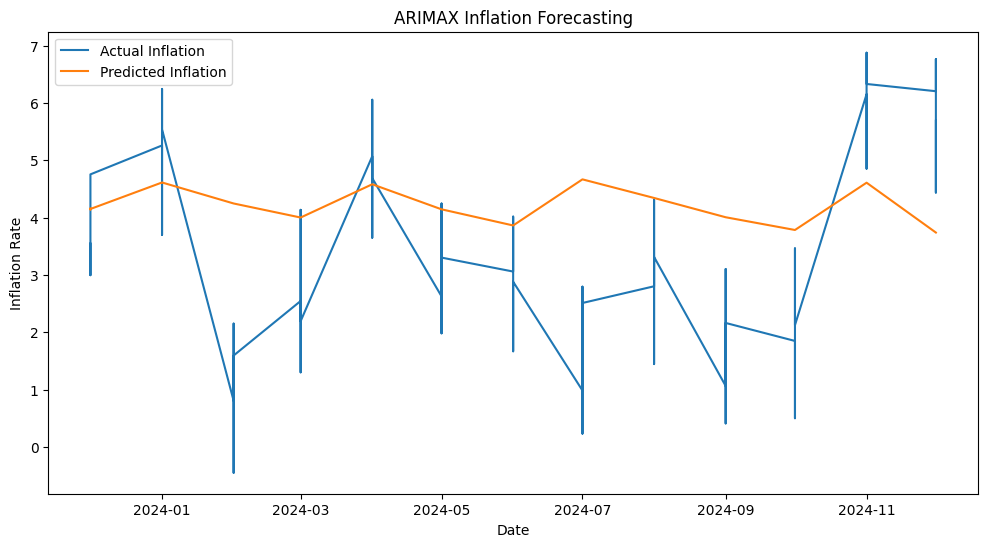

In [11]:
plt.figure(figsize=(12,6))

plt.plot(test_y.index, test_y, label='Actual Inflation')
plt.plot(test_y.index, predictions, label='Predicted Inflation')

plt.title('ARIMAX Inflation Forecasting')
plt.xlabel('Date')
plt.ylabel('Inflation Rate')
plt.legend()

plt.show()

In [12]:
comparison = pd.DataFrame({
    'Actual': test_y.values,
    'Predicted': predictions.values
})

print("\n==============================")
print("Actual vs Predicted")
print("==============================")

print(comparison.head())


Actual vs Predicted
     Actual  Predicted
0  3.546184   4.157641
1  4.010000   4.141100
2  3.432751   4.156002
3  3.594121   4.146307
4  4.176489   4.152761
